In [1]:
print("AI Resume Screening Project Started!")


AI Resume Screening Project Started!


In [2]:
resumes = [
    {
        "name": "Candidate 1",
        "resume": """
        Python Developer with 2 years of experience.
        Skills: Python, SQL, Pandas, NumPy, Machine Learning,
        Scikit-learn, Git and Flask.
        Experience in developing data analysis and machine learning projects.
        """
    },
    
    {
        "name": "Candidate 2",
        "resume": """
        Java Developer with 3 years of experience.
        Skills: Java, Spring Boot, MySQL, HTML, CSS and Git.
        Experience in developing web applications and backend services.
        """
    },
    
    {
        "name": "Candidate 3",
        "resume": """
        Data Science student with experience in Python.
        Skills: Python, Pandas, NumPy, SQL, Machine Learning,
        Deep Learning and TensorFlow.
        Experience in data analysis and prediction projects.
        """
    },
    
    {
        "name": "Candidate 4",
        "resume": """
        Web Developer with 2 years of experience.
        Skills: HTML, CSS, JavaScript, React, Node.js and MongoDB.
        Experience in building web applications.
        """
    }
]

print("Number of resumes:", len(resumes))


Number of resumes: 4


In [3]:
job_description = """
We are looking for a Python Developer with experience in
Python, SQL, Pandas, NumPy and Machine Learning.

The candidate should have knowledge of Scikit-learn,
data analysis, Git and Flask.
"""

print(job_description)



We are looking for a Python Developer with experience in
Python, SQL, Pandas, NumPy and Machine Learning.

The candidate should have knowledge of Scikit-learn,
data analysis, Git and Flask.



In [4]:
import pandas as pd

df = pd.DataFrame(resumes)

df


,name,resume
0,Candidate 1,\n Python Developer with 2 years of exp...
1,Candidate 2,\n Java Developer with 3 years of exper...
2,Candidate 3,\n Data Science student with experience...
3,Candidate 4,\n Web Developer with 2 years of experi...


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Resume text निकालना
resume_texts = [resume["resume"] for resume in resumes]

# Resume + Job Description को एक साथ process करना
documents = resume_texts + [job_description]

# TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(documents)

# Job description आखिरी document है
job_vector = tfidf_matrix[-1]

# सभी resumes की job description के साथ similarity
similarity_scores = cosine_similarity(
    tfidf_matrix[:-1],
    job_vector
).flatten()

print(similarity_scores)


[0.74793778 0.0964914  0.50036388 0.06603221]


In [7]:
results = []

for i, score in enumerate(similarity_scores):
    results.append({
        "Candidate": resumes[i]["name"],
        "Match Score": round(score * 100, 2)
    })

results_df = pd.DataFrame(results)

results_df


,Candidate,Match Score
0,Candidate 1,74.79
1,Candidate 2,9.65
2,Candidate 3,50.04
3,Candidate 4,6.60


In [8]:
results_df = results_df.sort_values(
    by="Match Score",
    ascending=False
).reset_index(drop=True)

results_df


,Candidate,Match Score
0,Candidate 1,74.79
1,Candidate 3,50.04
2,Candidate 2,9.65
3,Candidate 4,6.60


In [10]:
df = pd.read_csv('ai_resume_screening.csv')


In [1]:
import pandas as pd

df = pd.read_csv("AI_RESUME_SCREENING.csv")

print("Columns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())


Columns:
['years_experience', 'skills_match_score', 'education_level', 'project_count', 'resume_length', 'github_activity', 'shortlisted']

Shape:
(30000, 7)

First 5 rows:
   years_experience  skills_match_score education_level  project_count  \
0                 6                84.7       Bachelors              7   
1                 3                59.1         Masters              5   
2                12               100.0         Masters             12   
3                14                66.8     High School              8   
4                10                99.6       Bachelors             10   

   resume_length  github_activity shortlisted  
0            234              158          No  
1            502               77          No  
2            753              381         Yes  
3            529              407         Yes  
4            754              331         Yes  


In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load dataset
df = pd.read_csv("AI_RESUME_SCREENING.csv")

# Remove unnecessary spaces from column names
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# -----------------------------
# Features and target
# -----------------------------

X = df.drop("shortlisted", axis=1)
y = df["shortlisted"]

# Convert Yes/No into 1/0
y = y.map({
    "Yes": 1,
    "No": 0
})

# -----------------------------
# Feature types
# -----------------------------

numeric_features = [
    "years_experience",
    "skills_match_score",
    "project_count",
    "resume_length",
    "github_activity"
]

categorical_features = [
    "education_level"
]

# -----------------------------
# Preprocessing
# -----------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# -----------------------------
# Model
# -----------------------------

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# -----------------------------
# Train/Test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -----------------------------
# Train
# -----------------------------

pipeline.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred = pipeline.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Shortlisted", "Shortlisted"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Dataset shape: (30000, 7)

Columns:
['years_experience', 'skills_match_score', 'education_level', 'project_count', 'resume_length', 'github_activity', 'shortlisted']

Accuracy: 89.82 %

Classification Report:
                 precision    recall  f1-score   support

Not Shortlisted       0.81      0.87      0.84      1807
    Shortlisted       0.94      0.91      0.93      4193

       accuracy                           0.90      6000
      macro avg       0.87      0.89      0.88      6000
   weighted avg       0.90      0.90      0.90      6000


Confusion Matrix:
[[1574  233]
 [ 378 3815]]


Matplotlib is building the font cache; this may take a moment.


                                    Feature  Importance
0                 numeric__years_experience    0.306836
4                  numeric__github_activity    0.220370
2                    numeric__project_count    0.169541
1               numeric__skills_match_score    0.150393
3                    numeric__resume_length    0.121146
7      categorical__education_level_Masters    0.008420
6  categorical__education_level_High School    0.008350
8          categorical__education_level_PhD    0.007725
5    categorical__education_level_Bachelors    0.007218


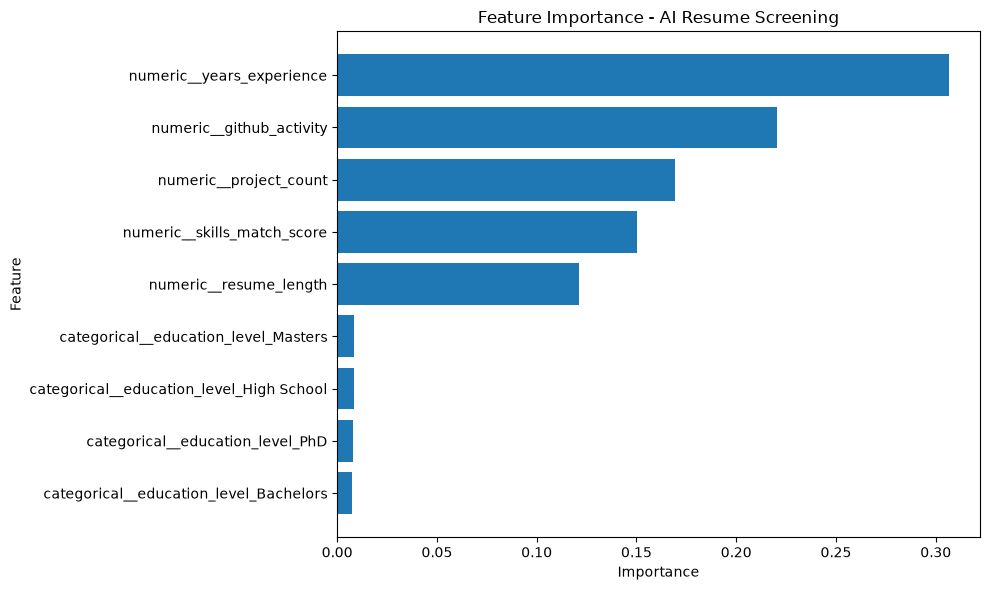

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Get transformed feature names
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance
importances = pipeline.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - AI Resume Screening")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
